# 03 Study area selection

Locates the study district in the national distribution, and shows that the
choice does not depend on where any cut-off is placed.

Two measures are put side by side. Record currency, the share of a district's
water point records dated 2020 or later, decides whether the model can be run
there at all. The census share of households on an unimproved main source
describes how much unmet need there is.

Three points about the measures, each of which changes the answer if got wrong.

Record currency is computed over the **whole inventory**, not over candidates.
The currency of a district's records reflects the mapping exercise, not which of
its points happen to be broken.

Twenty-six district level units are **excluded**. Ten cities became separate
local governments on 1 July 2020, and Terego and Butebo were created from Arua
and Pallisa; records predating those changes carry the parent's name, so parent
and child cannot be placed on a common footing. Apaa is a disputed area. The
study district is unaffected: its point count is identical whether taken from
the recorded district name or from a spatial join.

The horizontal axis is a **district wide** census measure used for selection
only. The optimisation that follows is restricted to rural population cells.

In [1]:
import sys
from pathlib import Path

# config.py sits beside the notebooks, so the working directory is enough. If a
# notebook is run from elsewhere, walk up until it is found.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
sys.path.insert(0, str(ROOT))
from config import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for f in (ANALYSIS_SAMPLE, CANDIDATES_NAT, CENSUS_HIER):
    print(f"{'ok ' if f.exists() else 'MISSING':8s}{f.name}")

ok      analysis_sample.csv
ok      candidates_national.csv
ok      census_hierarchy.csv


## 1. Record currency, from the full inventory

In [2]:
s = pd.read_csv(ANALYSIS_SAMPLE, low_memory=False)
s["yr"] = pd.to_datetime(s["#report_date"], errors="coerce", format="mixed").dt.year
s = s[~s.district.isin(EXCLUDED_DISTRICTS)]

rec = s.groupby("district").agg(n_records=("district", "size"),
                                recency=("yr", lambda v: (v >= RECENT_FROM).mean()))

cn = pd.read_csv(CANDIDATES_NAT, low_memory=False)
cn = cn[~cn.district.isin(EXCLUDED_DISTRICTS)]
ncand = cn.groupby("district").size().rename("n_cand")

rec = rec.join(ncand).fillna({"n_cand": 0})
print(f"districts compared:      {len(rec)}")
print(f"national median recency: {rec.recency.median():.3f}")

districts compared:      120
national median recency: 0.000


Two districts worth printing now, because they carry the argument later. One
has the most candidates of any eligible district, the other has the highest
unmet need among those compared and no candidates at all.

In [3]:
for name in (DISTRICT.upper(), "KAZO"):
    if name in rec.index:
        r = rec.loc[name]
        print(f"{name:10s} records {r.n_records:6,.0f}   "
              f"recency {r.recency:.3f}   candidates {r.n_cand:5,.0f}")
    else:
        print(f"{name:10s} missing")

KIKUUBE    records  1,733   recency 0.729   candidates   320
KAZO       records     22   recency 0.773   candidates     0


## 2. Unmet need, from the census

The district level rows of the hierarchy built in 02. Reading them from that
file rather than reparsing the workbook keeps one definition of a district row.

In [4]:
H = pd.read_csv(CENSUS_HIER)
cen = (H[H.level == "district"]
       .assign(district=lambda t: t.name.str.upper().str.strip())
       .set_index("district")[["unimproved_share"]]
       .rename(columns={"unimproved_share": "unimp"}))
cen = cen[~cen.index.isin(EXCLUDED_DISTRICTS)]

df = rec.join(cen, how="left").reset_index()
missing = df[df.unimp.isna()]
print(f"census share matched for {df.unimp.notna().sum()} of {len(df)} districts")
if len(missing):
    print("unmatched:", sorted(missing.district))

census share matched for 120 of 120 districts


## 3. Ranked distribution

The obvious way to define an eligible set is to find a break in the ranked
distribution and take everything above it. That is tested first.

In [5]:
d = df.sort_values("recency", ascending=False).reset_index(drop=True)
print("top of the recency ranking:")
print(d.head(10)[["district", "n_records", "recency", "n_cand", "unimp"]]
      .to_string(index=False))

step = d.recency.values[:-1] - d.recency.values[1:]
order = np.argsort(-step)

print("\nfive largest gaps in the ranked distribution")
for j in order[:5]:
    print(f"  between rank {j + 1:3d} ({d.recency[j]:.3f}) and rank {j + 2:3d} "
          f"({d.recency[j + 1]:.3f}):  {step[j]:.3f}")

cut = int(order[0]) + 1
print(f"\nlargest gap is {step[order[0]] / step[order[1]]:.1f} times the second largest")
print(f"districts above it: {cut}")
print(f"districts below 1 per cent recency: {(d.recency < 0.01).sum()}")

top of the recency ranking:
   district  n_records  recency  n_cand    unimp
      LUUKA        878 0.785877    60.0 0.014047
       KAZO         22 0.772727     0.0 0.617138
KIRYANDONGO       1110 0.755856   172.0 0.107987
    KIKUUBE       1733 0.728794   320.0 0.346737
    MASINDI       2153 0.673943   243.0 0.099630
     MAYUGE       1243 0.669348    50.0 0.141085
    LUWEERO       1027 0.324245   108.0 0.090223
   KYENJOJO       1020 0.188235   221.0 0.470734
     WAKISO       1459 0.150103   220.0 0.095499
     IBANDA         97 0.123711    11.0 0.356226

five largest gaps in the ranked distribution
  between rank   6 (0.669) and rank   7 (0.324):  0.345
  between rank   7 (0.324) and rank   8 (0.188):  0.136
  between rank  13 (0.092) and rank  14 (0.036):  0.055
  between rank   4 (0.729) and rank   5 (0.674):  0.055
  between rank   8 (0.188) and rank   9 (0.150):  0.038

largest gap is 2.5 times the second largest
districts above it: 6
districts below 1 per cent recency: 93


## 4. Selection without a cut-off

Rather than defend one cut-off, the selection is repeated across a range of
them. Two conditions apply at each: a wholly urban unit falls outside the rural
scope of the study, and a district with no candidates has nothing to select
from. Among what remains, the district with the most unmet need is taken.

In [6]:
d = df.sort_values("recency", ascending=False).reset_index(drop=True)
d["is_urban_unit"] = d.district.isin(URBAN_UNITS)

for thr in CUTS:
    e = d[(d.recency >= thr) & (~d.is_urban_unit) & (d.n_cand > 0)]
    pick = e.loc[e.unimp.idxmax()].district if len(e) else "none"
    print(f"threshold {thr:.0%}  above {(d.recency >= thr).sum():3d}"
          f"  modellable {len(e):2d}  selected {pick}")

threshold 20%  above   7  modellable  6  selected KIKUUBE
threshold 30%  above   7  modellable  6  selected KIKUUBE
threshold 40%  above   6  modellable  5  selected KIKUUBE
threshold 50%  above   6  modellable  5  selected KIKUUBE
threshold 60%  above   6  modellable  5  selected KIKUUBE
threshold 70%  above   4  modellable  3  selected KIKUUBE


The same district is selected at every cut-off, so no cut-off has to be
justified.

## 5. Figure

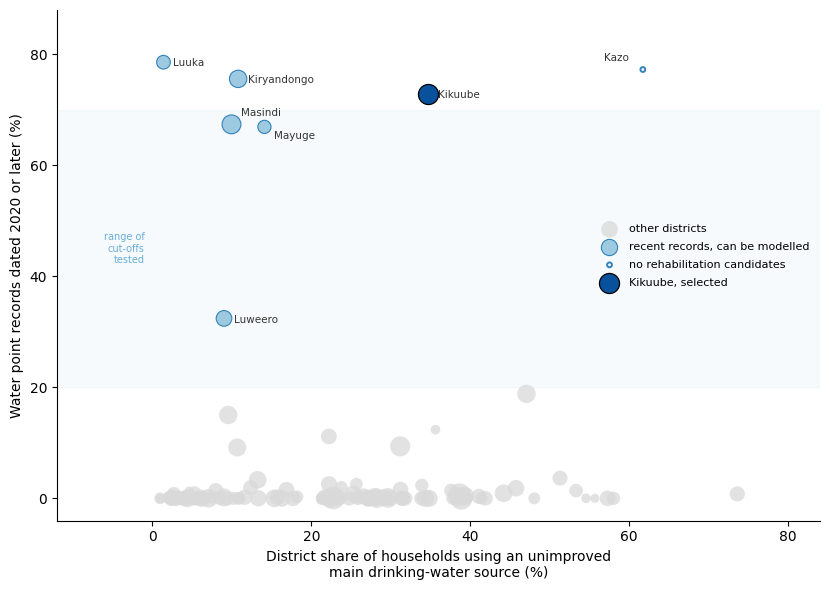

In [7]:
d = df.sort_values("recency", ascending=False).reset_index(drop=True)
d["is_urban_unit"] = d.district.isin(URBAN_UNITS)

LABEL_ABOVE = min(CUTS)
modellable = ~d.is_urban_unit & (d.n_cand > 0)
inband = d.recency >= LABEL_ABOVE

grp_other = d[~inband]
grp_model = d[inband & modellable & (d.district != DISTRICT.upper())]
grp_urban = d[inband & d.is_urban_unit]
grp_empty = d[inband & ~d.is_urban_unit & (d.n_cand == 0)]
grp_pick = d[d.district == DISTRICT.upper()]


def msize(n):
    """Square root scaling so a district with no candidates stays visibly small."""
    return 12 + np.sqrt(np.asarray(n, float)) * 11


fig, ax = plt.subplots(figsize=(8.4, 6))

ax.axhspan(min(CUTS) * 100, max(CUTS) * 100, color="#3182bd", alpha=0.04, zorder=0)
ax.text(-1, (min(CUTS) + max(CUTS)) / 2 * 100, "range of\ncut-offs\ntested",
        fontsize=7, color="#6baed6", va="center", ha="right")

ax.scatter(grp_other.unimp * 100, grp_other.recency * 100,
           s=msize(grp_other.n_cand), c="#d9d9d9", edgecolor="none",
           alpha=0.75, zorder=2, label="other districts")

ax.scatter(grp_model.unimp * 100, grp_model.recency * 100,
           s=msize(grp_model.n_cand), c="#9ecae1", edgecolor="#3182bd",
           linewidth=0.8, zorder=3, label="recent records, can be modelled")

if len(grp_urban):
    ax.scatter(grp_urban.unimp * 100, grp_urban.recency * 100,
               s=msize(grp_urban.n_cand), facecolors="none", edgecolor="#3182bd",
               linewidth=1.2, linestyle="--", zorder=3,
               label="wholly urban unit, outside rural scope")

ax.scatter(grp_empty.unimp * 100, grp_empty.recency * 100,
           s=msize(grp_empty.n_cand), facecolors="none", edgecolor="#3182bd",
           linewidth=1.4, zorder=3, label="no rehabilitation candidates")

ax.scatter(grp_pick.unimp * 100, grp_pick.recency * 100,
           s=msize(grp_pick.n_cand), c="#08519c", edgecolor="black",
           linewidth=0.9, zorder=4, label=f"{DISTRICT}, selected")

# Manual offsets for the few labels that would otherwise collide
NUDGE = {"MASINDI": (7, 6), "MAYUGE": (7, -9), "KAZO": (-10, 6)}
for _, r in d[inband].iterrows():
    dx, dy = NUDGE.get(r.district, (7, -3))
    ax.annotate(r.district.title(), (r.unimp * 100, r.recency * 100),
                xytext=(dx, dy), textcoords="offset points",
                fontsize=7.5, color="#333333", zorder=5,
                ha="right" if dx < 0 else "left")

ax.set_xlabel("District share of households using an unimproved\n"
              "main drinking-water source (%)")
ax.set_ylabel(f"Water point records dated {RECENT_FROM} or later (%)")
ax.set_xlim(-12, 84)
ax.set_ylim(-4, 88)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper right", bbox_to_anchor=(1.0, 0.60),
          frameon=False, fontsize=8, labelspacing=0.7)

plt.tight_layout()
plt.savefig(FIG / "study_area_selection.png", dpi=300, bbox_inches="tight")
plt.show()

Figure note, for the caption:

> National positioning of Kikuube for case selection. Point size is the number of
> rehabilitation candidates and is descriptive only. Districts are taken from the
> district name recorded in the water point exchange, harmonised against the
> census spelling; twenty-six units affected by the 2020 city separations, by the
> creation of Terego and Butebo, or by the Apaa dispute are excluded, since
> records predating those changes carry the parent's name. The shaded band spans
> the cut-offs tested for record currency; Kikuube has the highest share of
> households without an improved source among districts that can be modelled at
> every one of them. Hollow markers cannot support the analysis: Kazo has no
> rehabilitation candidates despite having recent records and the highest
> unimproved share among the districts compared. The horizontal axis is a
> district-wide census measure used for selection only; the optimisation that
> follows is restricted to rural population cells.

## 6. What to report

In [8]:
d = df.sort_values("recency", ascending=False).reset_index(drop=True)
step = d.recency.values[:-1] - d.recency.values[1:]
order = np.argsort(-step)
k = d[d.district == DISTRICT.upper()].iloc[0]

def rank_of(col):
    return int(d[col].rank(ascending=False)[d.district == DISTRICT.upper()].iloc[0])

print(f"districts compared                {len(d)}")
print(f"excluded from comparison          {len(EXCLUDED_DISTRICTS)}")
print(f"below 1 per cent recency          {(d.recency < 0.01).sum()}")
print(f"largest gap                       {step[order[0]]:.3f} at rank {order[0] + 1}")
print(f"second largest                    {step[order[1]]:.3f} at rank {order[1] + 1}")
print(f"ratio                             {step[order[0]] / step[order[1]]:.2f}")
print()
print(f"{DISTRICT}")
print(f"  records                         {k.n_records:,.0f}")
print(f"  recency                         {k.recency:.1%}, rank {rank_of('recency')}")
print(f"  candidates                      {k.n_cand:,.0f}, rank {rank_of('n_cand')}")
print(f"  unimproved share                {k.unimp:.1%}, rank {rank_of('unimp')}")

districts compared                120
excluded from comparison          26
below 1 per cent recency          93
largest gap                       0.345 at rank 6
second largest                    0.136 at rank 7
ratio                             2.54

Kikuube
  records                         1,733
  recency                         72.9%, rank 4
  candidates                      320, rank 5
  unimproved share                34.7%, rank 25


Eligible districts that cannot be modelled, and why.

In [10]:
d = df.sort_values("recency", ascending=False).reset_index(drop=True)
d["is_urban_unit"] = d.district.isin(URBAN_UNITS)
elig = d[d.recency >= min(CUTS)]
for _, r in elig.iterrows():
    reasons = []
    if r.is_urban_unit:
        reasons.append("wholly urban unit, outside the rural scope")
    if r.n_cand == 0:
        reasons.append("no candidates")
    if reasons:
        print(f"  {r.district:18s} {', '.join(reasons)}")

ok = (elig[~elig.is_urban_unit & (elig.n_cand > 0)]
      .sort_values("unimp", ascending=False))
print(f"\nremaining, ranked on unmet need")
print(ok[["district", "n_cand", "unimp", "recency"]].to_string(
    index=False, formatters={"unimp": "{:.1%}".format,
                             "recency": "{:.1%}".format,
                             "n_cand": "{:,.0f}".format}))

  KAZO               no candidates

remaining, ranked on unmet need
   district n_cand unimp recency
    KIKUUBE    320 34.7%   72.9%
     MAYUGE     50 14.1%   66.9%
KIRYANDONGO    172 10.8%   75.6%
    MASINDI    243 10.0%   67.4%
    LUWEERO    108  9.0%   32.4%
      LUUKA     60  1.4%   78.6%
